Import Library dan Pemeriksaan Dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00601/ai4i2020.csv"
df = pd.read_csv(url)

print("=== 5 BARIS PERTAMA DATASET ===")
display(df.head())

print("\n=== DIMENSI DATASET (SHAPE) ===")
print(df.shape)

print("\n=== INFORMASI DATASET (INFO) ===")
df.info()

print("\n=== STATISTIK DESKRIPTIF ===")
display(df.describe())

=== 5 BARIS PERTAMA DATASET ===


,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0



=== DIMENSI DATASET (SHAPE) ===
(10000, 14)

=== INFORMASI DATASET (INFO) ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  object 
 2   Type                     10000 non-null  object 
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Machine failure          10000 non-null  int64  
 9   TWF                      10000 non-null  int64  
 10  HDF                      10000 non-null  int64  
 11  PWF                      10000 non-null  int64  
 12  OSF                      10000 non-null  int64  
 13

,UDI,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000
mean,5000.50000,300.004930,310.005560,1538.776100,39.986910,107.951000,0.033900,0.004600,0.011500,0.009500,0.009800,0.00190
std,2886.89568,2.000259,1.483734,179.284096,9.968934,63.654147,0.180981,0.067671,0.106625,0.097009,0.098514,0.04355
min,1.00000,295.300000,305.700000,1168.000000,3.800000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
25%,2500.75000,298.300000,308.800000,1423.000000,33.200000,53.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
50%,5000.50000,300.100000,310.100000,1503.000000,40.100000,108.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
75%,7500.25000,301.500000,311.100000,1612.000000,46.800000,162.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
max,10000.00000,304.500000,313.800000,2886.000000,76.600000,253.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000


Preprocessing

In [2]:
# 1. Pemeriksaan Missing Value
print("=== MISSING VALUE ===")
print(df.isnull().sum())

# 2. Pemeriksaan Duplikat
print("\n=== DUPLIKAT ===")
jumlah_duplikat = df.duplicated().sum()
print(f"Jumlah baris duplikat: {jumlah_duplikat}")

# Menghapus duplikat jika ada
if jumlah_duplikat > 0:
    df = df.drop_duplicates()
    print(f"Duplikat berhasil dihapus. Sisa baris sekarang: {len(df)}")

# 3. Pencegahan Data Leakage & Penghapusan Identifier,
# UDI dan Product ID dihapus karena hanya identifier.
# TWF, HDF, PWF, OSF, RNF dihapus untuk mencegah Data Leakage.
kolom_dihapus = ['UDI', 'Product ID', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF']
df_clean = df.drop(columns=kolom_dihapus)

print("\n=== KOLOM SETELAH PENGHAPUSAN IDENTIFIER & PENCEGAHAN LEAKAGE ===")
print(df_clean.columns.tolist())

# 4. Encoding Data Kategorikal
# Menggunakan One-Hot Encoding untuk kolom 'Type'
df_encoded = pd.get_dummies(df_clean, columns=['Type'], drop_first=True)

# 5. Hasil Akhir Preprocessing
print("\n=== DIMENSI DATASET SETELAH PREPROCESSING ===")
print(df_encoded.shape)

print("\n=== 5 BARIS PERTAMA SETELAH PREPROCESSING ===")
display(df_encoded.head())

=== MISSING VALUE ===
UDI                        0
Product ID                 0
Type                       0
Air temperature [K]        0
Process temperature [K]    0
Rotational speed [rpm]     0
Torque [Nm]                0
Tool wear [min]            0
Machine failure            0
TWF                        0
HDF                        0
PWF                        0
OSF                        0
RNF                        0
dtype: int64

=== DUPLIKAT ===
Jumlah baris duplikat: 0

=== KOLOM SETELAH PENGHAPUSAN IDENTIFIER & PENCEGAHAN LEAKAGE ===
['Type', 'Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]', 'Machine failure']

=== DIMENSI DATASET SETELAH PREPROCESSING ===
(10000, 8)

=== 5 BARIS PERTAMA SETELAH PREPROCESSING ===


,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,Type_L,Type_M
0,298.1,308.6,1551,42.8,0,0,False,True
1,298.2,308.7,1408,46.3,3,0,True,False
2,298.1,308.5,1498,49.4,5,0,True,False
3,298.2,308.6,1433,39.5,7,0,True,False
4,298.2,308.7,1408,40.0,9,0,True,False


Exploratory Data Analysis (EDA)

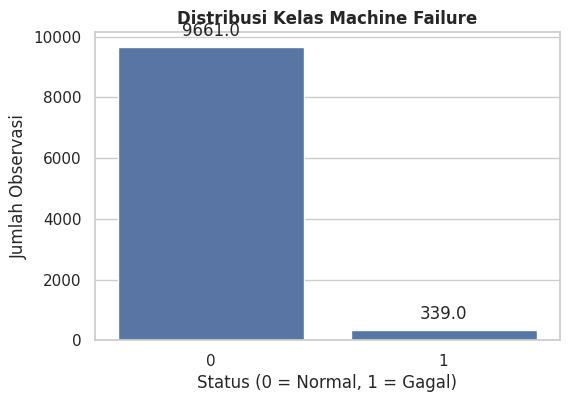

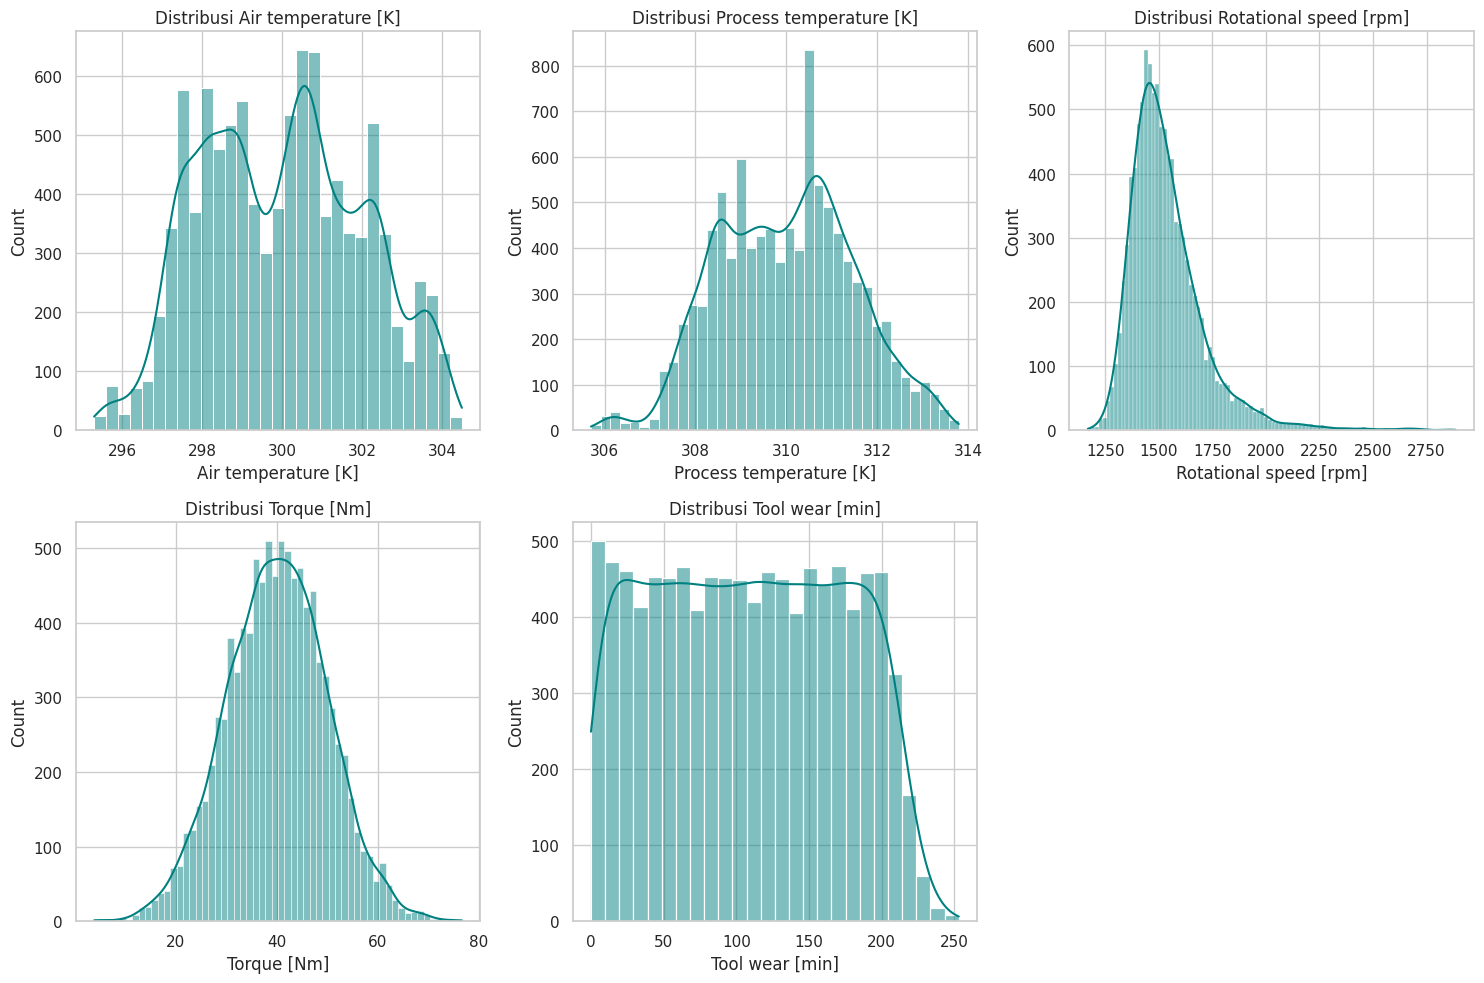

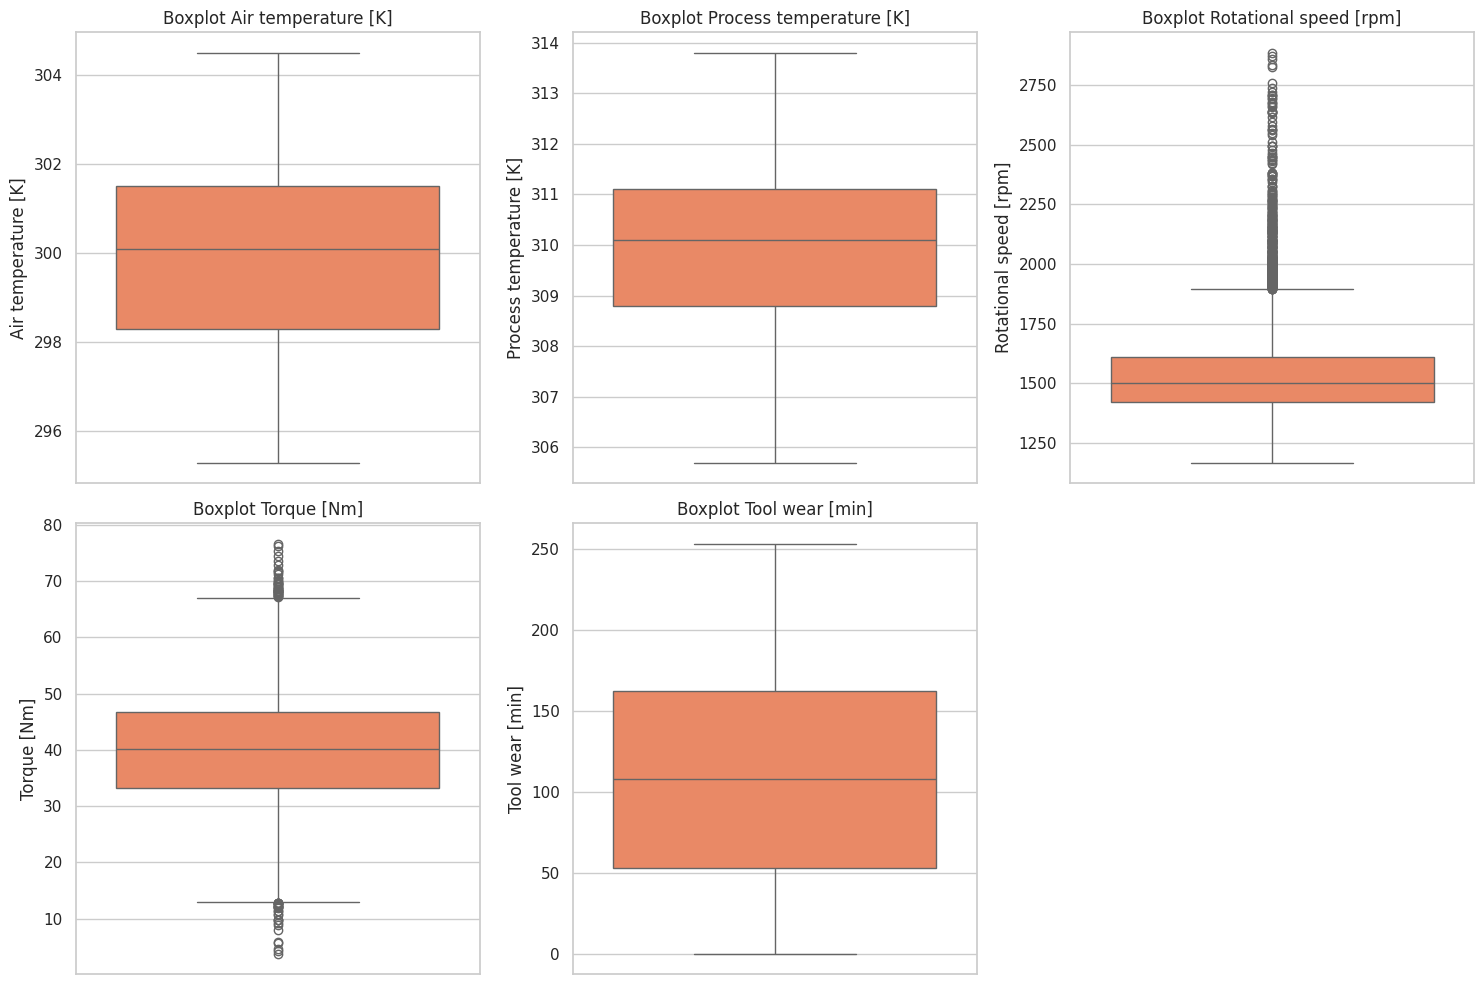

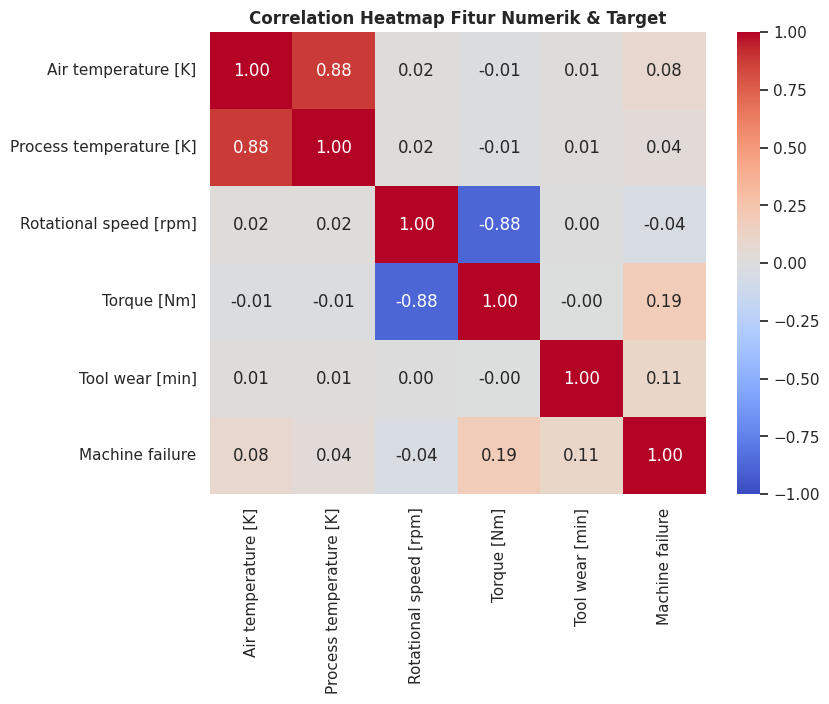

In [3]:
# Mengatur gaya visualisasi
sns.set_theme(style="whitegrid")

# 1. Distribusi Target (Class Imbalance)
plt.figure(figsize=(6, 4))
ax = sns.countplot(data=df_encoded, x='Machine failure')
plt.title('Distribusi Kelas Machine Failure', fontweight='bold')
plt.xlabel('Status (0 = Normal, 1 = Gagal)')
plt.ylabel('Jumlah Observasi')

# Menambahkan label angka di atas bar
for p in ax.patches:
    ax.annotate(f'{p.get_height()}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', xytext=(0, 5), textcoords='offset points')
plt.show()

# Memisahkan fitur numerik murni untuk analisis lanjutan
fitur_numerik = ['Air temperature [K]', 'Process temperature [K]',
                 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]']

# 2. Histogram untuk Distribusi Fitur Numerik
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for i, col in enumerate(fitur_numerik):
    sns.histplot(df_encoded[col], kde=True, ax=axes[i], color='teal')
    axes[i].set_title(f'Distribusi {col}')

# Menghapus plot kosong (karena kita punya 5 fitur tapi 6 grid)
fig.delaxes(axes[5])
plt.tight_layout()
plt.show()

# 3. Boxplot untuk Deteksi Outlier
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for i, col in enumerate(fitur_numerik):
    sns.boxplot(y=df_encoded[col], ax=axes[i], color='coral')
    axes[i].set_title(f'Boxplot {col}')

fig.delaxes(axes[5])
plt.tight_layout()
plt.show()

# 4. Correlation Heatmap
plt.figure(figsize=(8, 6))
korelasi = df_encoded[fitur_numerik + ['Machine failure']].corr()
sns.heatmap(korelasi, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1)
plt.title('Correlation Heatmap Fitur Numerik & Target', fontweight='bold')
plt.show()

Pemisahan X dan y, Train-Test Split, & Standardisasi

In [4]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 1. Pemisahan X dan y
X = df_encoded.drop(columns=['Machine failure'])
y = df_encoded['Machine failure']

# 2. Train-Test Split (80% Training, 20% Testing)
# random_state=42 untuk reproduksibilitas
# stratify=y sangat penting untuk menangani class imbalance
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("=== DIMENSI DATA SETELAH SPLIT ===")
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

# Verifikasi Stratify (Proporsi kelas gagal)
print("\n=== PROPORSI KELAS 1 (GAGAL) ===")
print(f"Proporsi di y_train: {y_train.mean():.4f}")
print(f"Proporsi di y_test: {y_test.mean():.4f}")

# 3. Standardisasi
scaler = StandardScaler()

# Scaler HANYA fit pada X_train, kemudian transform X_train dan X_test
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Mengembalikan ke bentuk DataFrame agar lebih mudah dibaca (opsional)
# Memastikan indeks asli dipertahankan
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X.columns, index=X_test.index)

print("\n=== 5 BARIS PERTAMA X_TRAIN SETELAH STANDARDISASI ===")
display(X_train_scaled.head())

=== DIMENSI DATA SETELAH SPLIT ===
X_train shape: (8000, 7)
X_test shape: (2000, 7)
y_train shape: (8000,)
y_test shape: (2000,)

=== PROPORSI KELAS 1 (GAGAL) ===
Proporsi di y_train: 0.0339
Proporsi di y_test: 0.0340

=== 5 BARIS PERTAMA X_TRAIN SETELAH STANDARDISASI ===


,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Type_L,Type_M
4058,0.998914,0.604282,-0.460607,0.718305,-0.843997,-1.234366,1.536207
1221,-1.505194,-1.153260,-0.775574,0.638456,0.382263,-1.234366,1.536207
6895,0.498092,1.077466,-1.007654,0.558607,0.460870,-1.234366,1.536207
9863,-0.553633,-0.139294,-0.709265,1.626586,-0.372359,0.810133,-0.650954
8711,-1.455112,-1.018064,1.070019,-1.128202,-0.906882,0.810133,-0.650954


Training Model (Logistic Regression & Random Forest)

In [5]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# 1. Inisialisasi Model
# Menggunakan random_state=42 agar hasil eksperimen dapat direproduksi
logreg_model = LogisticRegression(random_state=42)
rf_model = RandomForestClassifier(random_state=42)

# 2. Proses Training (HANYA menggunakan data training
print("=== PROSES TRAINING DIMULAI ===")

# Melatih Logistic Regression
logreg_model.fit(X_train_scaled, y_train)
print("1. Logistic Regression berhasil dilatih.")

# Melatih Random Forest
rf_model.fit(X_train_scaled, y_train)
print("2. Random Forest berhasil dilatih.")

print("=== PROSES TRAINING SELESAI ===")

=== PROSES TRAINING DIMULAI ===
1. Logistic Regression berhasil dilatih.
2. Random Forest berhasil dilatih.
=== PROSES TRAINING SELESAI ===


Evaluation & Confusion Matrix

=== EVALUASI LOGISTIC REGRESSION ===
              precision    recall  f1-score   support

           0       0.97      1.00      0.98      1932
           1       0.64      0.10      0.18        68

    accuracy                           0.97      2000
   macro avg       0.80      0.55      0.58      2000
weighted avg       0.96      0.97      0.96      2000


=== EVALUASI RANDOM FOREST ===
              precision    recall  f1-score   support

           0       0.98      1.00      0.99      1932
           1       0.88      0.53      0.66        68

    accuracy                           0.98      2000
   macro avg       0.93      0.76      0.83      2000
weighted avg       0.98      0.98      0.98      2000



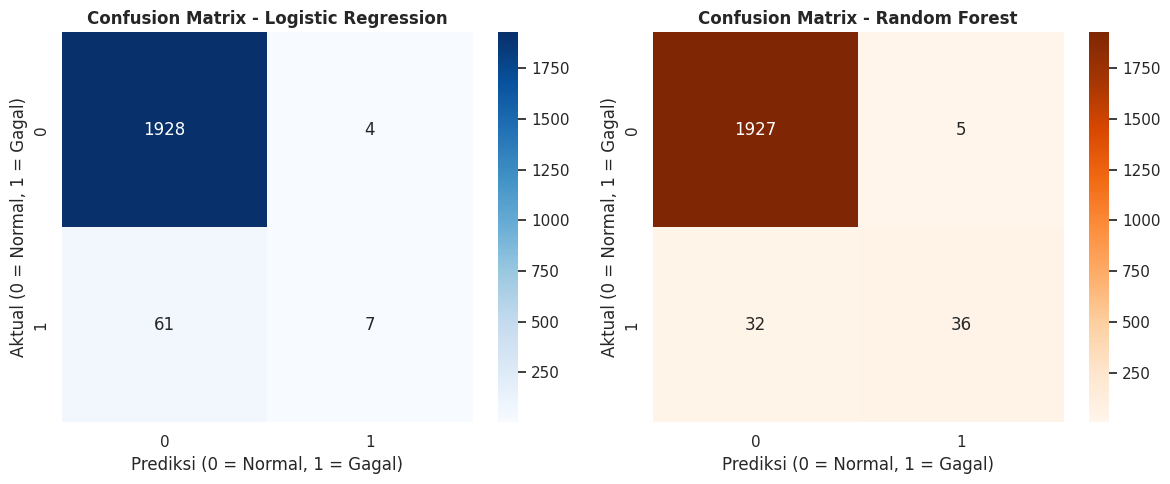

In [6]:
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Melakukan Prediksi pada Data Testing
y_pred_logreg = logreg_model.predict(X_test_scaled)
y_pred_rf = rf_model.predict(X_test_scaled)

# 2. Evaluasi Metrik Klasifikasi
print("=== EVALUASI LOGISTIC REGRESSION ===")
print(classification_report(y_test, y_pred_logreg))

print("\n=== EVALUASI RANDOM FOREST ===")
print(classification_report(y_test, y_pred_rf))

# 3. Visualisasi Confusion Matrix
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Confusion Matrix Logistic Regression
cm_logreg = confusion_matrix(y_test, y_pred_logreg)
sns.heatmap(cm_logreg, annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title('Confusion Matrix - Logistic Regression', fontweight='bold')
axes[0].set_xlabel('Prediksi (0 = Normal, 1 = Gagal)')
axes[0].set_ylabel('Aktual (0 = Normal, 1 = Gagal)')

# Confusion Matrix Random Forest
cm_rf = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Oranges', ax=axes[1])
axes[1].set_title('Confusion Matrix - Random Forest', fontweight='bold')
axes[1].set_xlabel('Prediksi (0 = Normal, 1 = Gagal)')
axes[1].set_ylabel('Aktual (0 = Normal, 1 = Gagal)')

plt.tight_layout()
plt.show()

Prediksi Sampel & Feature Importance

=== CONTOH PREDIKSI PADA 10 SAMPEL ACAK ===


,Kondisi Aktual,Prediksi LogReg,Prediksi Random Forest
0,0,0,0
1,0,0,0
2,0,0,0
3,0,0,0
4,0,0,0
5,0,0,0
6,0,0,0
7,0,0,0
8,1,0,0
9,0,0,0



=== NILAI FEATURE IMPORTANCE ===


,Fitur,Importance
3,Torque [Nm],0.325802
2,Rotational speed [rpm],0.227445
4,Tool wear [min],0.170059
0,Air temperature [K],0.133696
1,Process temperature [K],0.116563
5,Type_L,0.016373
6,Type_M,0.010063


/tmp/ipykernel_1119/3250082969.py:41: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_importance, x='Importance', y='Fitur', palette='viridis')


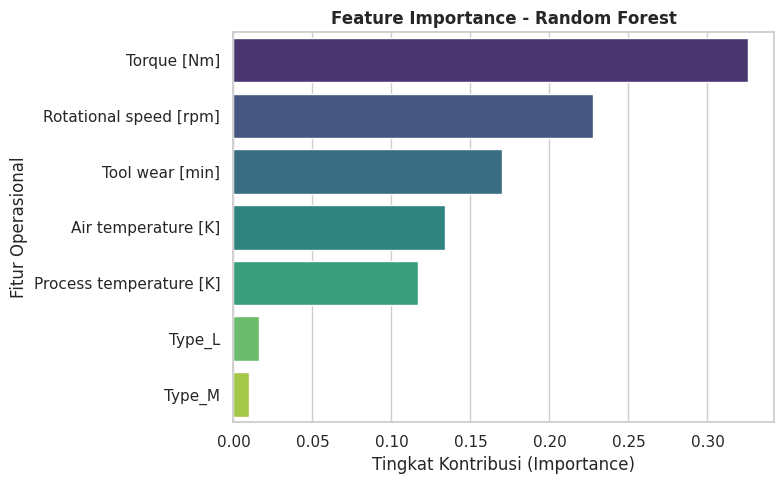

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Prediksi Sampel
# Mengambil 10 sampel secara acak dari data testing
sample_X = X_test_scaled.sample(10, random_state=42)

# PERBAIKAN: Menggunakan .iloc agar posisi baris sinkron dengan indeks baru X_test_scaled
sample_y = y_test.loc[sample_X.index]

pred_logreg_sample = logreg_model.predict(sample_X)
pred_rf_sample = rf_model.predict(sample_X)

df_sample = pd.DataFrame({
    'Kondisi Aktual': sample_y.values,
    'Prediksi LogReg': pred_logreg_sample,
    'Prediksi Random Forest': pred_rf_sample
})

print("=== CONTOH PREDIKSI PADA 10 SAMPEL ACAK ===")
display(df_sample)

# 2. Feature Importance dari Random Forest
importances = rf_model.feature_importances_
fitur_names = X.columns

df_importance = pd.DataFrame({
    'Fitur': fitur_names,
    'Importance': importances
})
# Mengurutkan dari yang paling penting
df_importance = df_importance.sort_values(by='Importance', ascending=False)

print("\n=== NILAI FEATURE IMPORTANCE ===")
display(df_importance)

# Visualisasi Feature Importance
plt.figure(figsize=(8, 5))
sns.barplot(data=df_importance, x='Importance', y='Fitur', palette='viridis')
plt.title('Feature Importance - Random Forest', fontweight='bold')
plt.xlabel('Tingkat Kontribusi (Importance)')
plt.ylabel('Fitur Operasional')
plt.tight_layout()
plt.show()